# CHEASE fixed-boundary sensitivity scans: requested, materialized, achieved

> How does a controlled change to pressure, current-profile shape, or the prescribed plasma shape propagate through a CHEASE fixed-boundary solve into β, l_i, q, magnetic shear and the rational surfaces?

This page is a **controlled, local, fixed-boundary equilibrium sensitivity study** around one reference equilibrium: VEST 48224 at 300 ms, from its kinetic-EFIT lineage. Each scan point is its own CHEASE solve (`vaft.code.scan_chease`). The page is **not** any of the following:
- a transport or profile-evolution prediction;
- propagation of reconstruction uncertainty;
- a PF-coil, free-boundary or topology scan;
- evidence that the local sensitivities hold for every VEST regime.

**Scope beside the neighbouring pages.**
- `equilibrium_refinement_using_chease.ipynb` qualifies the single baseline refinement: boundary choice, profiles, conventions, and solver-mesh convergence.
- This page varies that baseline.
- Broad campaigns, continuation and resume belong to the scan engine (#66), not to a notebook.

**Requirements to run this page.** Sections 1-2 need only VAFT. Everything after them needs a CHEASE executable (`$CHEASEHOME/bin/chease`, `$CHEASE` or `$CHEASE_EXEC_DIR`); without one those sections say so and skip. The stored outputs come from a real run of 22 solves, taking roughly a quarter of an hour.

In [ ]:
from pathlib import Path
import os

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import contextlib
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft.omas
from vaft.code import CHEASEConfig, EquilibriumVariation, apply_equilibrium_variation, scan_chease
from vaft.code.chease import find_chease_executable
from vaft.data import read_geqdsk
from vaft.data.resources import data_path
from vaft.process.equilibrium import as_equilibrium, contour_shape_parameters, derive_global_descriptors
from vaft.validation.equilibrium import validate_equilibrium

source_path = data_path("kineticEfit/g048224.00300")
source = read_geqdsk(str(source_path))
_cleanup = contextlib.ExitStack()
workdir = Path(_cleanup.enter_context(tempfile.TemporaryDirectory(prefix="vaft-chease-scan-")))

# preserve_boundary_limiter=False: every case keeps CHEASE's own boundary, so a
# shape is measured from what was solved rather than from the outline the
# production path pastes back (see section 9).
config = CHEASEConfig(create_plot=False, preserve_boundary_limiter=False, timeout=900)
executable = find_chease_executable(config)
print(f"source: {source_path.name}   CHEASE: {executable or 'not found -- sections 3+ will skip'}")
print(f"solver mesh NS = NT = {config.resolved_mesh['ns']}, output box {config.nw}, target_psin {config.target_psin}")

source: g048224.00300   CHEASE: ~/git/chease/src-f90/chease
solver mesh NS = NT = 150, output box 513, target_psin 0.993


## 1. The baseline and how every case is described

Every case, the baseline included, is summarized by the same function, built on the common descriptors:
- `derive_global_descriptors`: geometry, `q`, shear, rational surfaces, `β_N`.
- `update_equilibrium_derived_profiles`: `β_p` and `l_i(3)`.
- `compute_grad_shafranov_residual`: local force balance.
- `validate_equilibrium`: the shared structure, convention and physical-validity checks, so that no threshold on this page is local to it.

Shape comes from `contour_shape_parameters` on the boundary itself. `derive_global_descriptors` reads triangularity off the highest boundary vertex, which is ill-conditioned on VEST's flat-topped boundary; that is filed as its own fix.

In [ ]:
RATIONAL_Q = (1.0, 1.5, 2.0, 3.0)


def describe(gfile):
    """The descriptors this page compares, for one g-file."""
    geqdsk = read_geqdsk(str(gfile))
    desc = derive_global_descriptors(as_equilibrium(geqdsk), rational_q=RATIONAL_Q)
    ods = geqdsk.to_omas()
    vaft.omas.update_equilibrium_derived_profiles(ods)
    gq = ods["equilibrium.time_slice.0.global_quantities"]
    psi_n = np.asarray(desc.radial_coordinates["psi_n"].value, dtype=float)
    shear = np.asarray(desc["magnetic_shear"].value, dtype=float)
    shape = contour_shape_parameters(np.asarray(geqdsk["RBBBS"]), np.asarray(geqdsk["ZBBBS"]))
    report = validate_equilibrium(ods, checks=("verification", "physical_validity"))
    flagged = sorted(
        name for section in ("verification", "physical_validity")
        for name, check in report[section].items()
        if isinstance(check, dict) and check.get("status") in ("warn", "fail")
    )
    row = {
        "beta_N": desc["beta_n"].value, "beta_p": float(gq["beta_pol"]), "li(3)": float(gq["li_3"]),
        "Ip [kA]": abs(desc["ip"].value) / 1e3, "q0": desc["q0"].value, "q95": desc["q95"].value,
        "shear@0.5": float(np.interp(0.5, psi_n, shear)),
        "R_axis [m]": desc["magnetic_axis_r"].value, "volume [m3]": desc["volume"].value,
        "kappa": shape["elongation"], "delta_u": shape["triangularity_upper"],
        "GS residual": float(np.nanmedian(vaft.omas.compute_grad_shafranov_residual(ods, time_slice=0).relative)),
        "validation": report["status"], "flags": ", ".join(flagged),
    }
    for q in RATIONAL_Q:
        found = [v.value for v in desc.rational_surfaces.get(q, ()) if v.value is not None]
        row[f"psi_N(q={q:g})"] = float(found[0]) if found else np.nan
    return row


baseline_row = describe(source_path)
print(pd.Series(baseline_row, name="EFIT 48224 @ 300 ms").to_string())

<repo>/vaft/data/eqdsk.py:1074: RuntimeWarning: q on axis is 8.07, 4.2x above its immediate neighbours (median 1.9); the toroidal flux integral carries that into rho_tor_norm. The profile is used as given -- see issue #317.


<repo>/vaft/omas/update.py:724: RuntimeWarning: q on axis is 8.07, 4.2x above its immediate neighbours (median 1.9); the toroidal flux integral carries that into rho_tor_norm. The profile is used as given -- see issue #317.


beta_N                                                  0.194592
beta_p                                                  0.022997
li(3)                                                   0.504465
Ip [kA]                                               143.167391
q0                                                      8.068292
q95                                                      5.82705
shear@0.5                                                 0.8618
R_axis [m]                                              0.427344
volume [m3]                                             1.022328
kappa                                                    1.74482
delta_u                                                  0.30371
GS residual                                             0.007671
validation                                                  warn
flags           pressure_profile, q_profile, virial_conditioning
psi_N(q=1)                                                   NaN
psi_N(q=1.5)             

The input already carries three validation flags:
- `virial_conditioning`: VEST's Shafranov-integral cancellation, #693.
- `pressure_profile`: the pressure is slightly negative somewhere.
- `q_profile`: `q` is not monotonic.

A scan point is judged by whether it is **worse than its input**, not against an empty flag list.

The input's `q0` of about 8 is a near-axis outlier in the stored EFIT profile (#317), and so are the input's `q = 2` and `q = 3` surfaces listed right at the axis. Every CHEASE case recomputes `q` and does not carry the outlier.

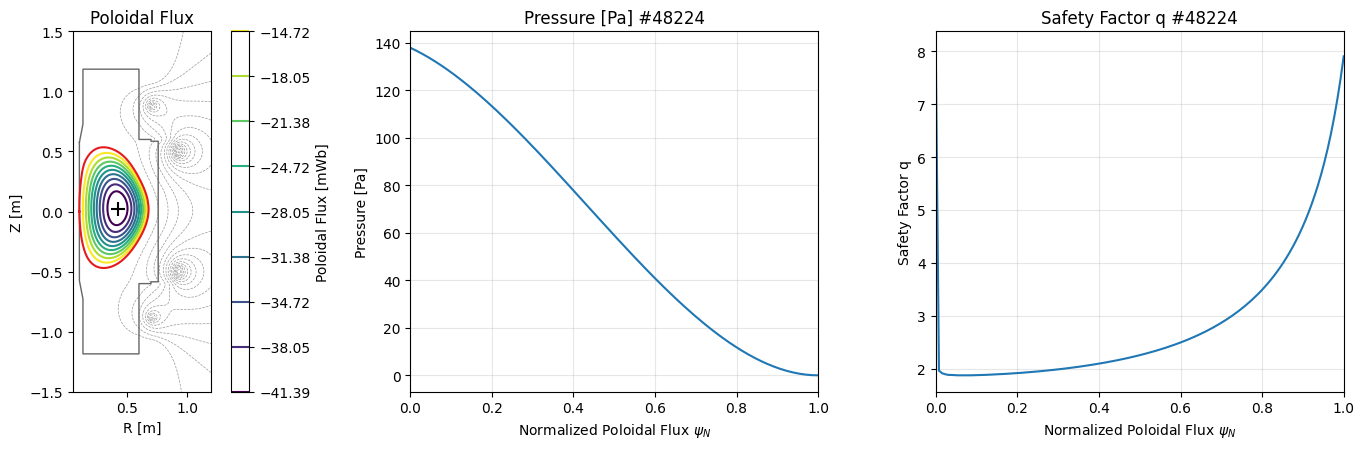

In [ ]:
source_ods = source.to_omas()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
vaft.omas.plot_equilibrium_field_psi(source_ods, label="EFIT 48224", ax=axes[0])
for ax, name in zip(axes[1:], ("equilibrium_profile_pressure", "equilibrium_profile_q")):
    vaft.omas.render_plot(name, [source_ods], label=["EFIT 48224"], coordinate="psi_norm", ax=ax)
fig.tight_layout()

## 2. What the four controls do to the input CHEASE reads

`EquilibriumVariation` has four controls. Each one acts on the three things `EXPEQ` carries: the boundary, `p'` (with the edge pressure), and `FF'`.

| control | acts on | meaning |
|---|---|---|
| `pressure_scale` | `PRES` and `PPRIME` together | same pressure shape, scaled amplitude |
| `current_peaking` = p | `FF'` → `FF'·(1-ψ_N)^p`, renormalized to keep `∫\|FF'\|dψ_N` | moves the current source toward the axis |
| `elongation_scale` | κ of the Miller fit to the source boundary | relative: 1.1 means 10% more than this discharge had |
| `triangularity_shift` | δ of the same Miller fit | additive |

A uniform `FF'` factor is **not** offered. With `ncscal = 1`, CHEASE rescales `p'` and `FF'` together until `q95` matches the source (`equilibrium_refinement_using_chease.ipynb`, section 8), so a constant `FF'` multiplier is exactly the degree of freedom it normalizes away. Redistribution survives that rescaling; amplitude does not.

The Miller controls are a shaping parameterization, not an actuator model. The Miller shape is up-down symmetric, has no X-point, and is not a coil or strike-point control.

The cell below applies each control to the source without running CHEASE.

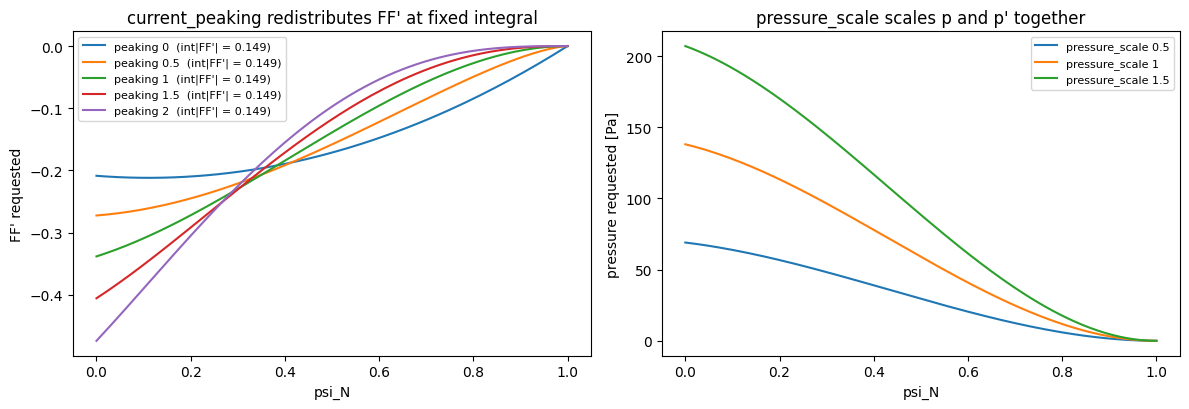

In [ ]:
psi_src = np.linspace(0.0, 1.0, len(source["FFPRIM"]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for c in (0.0, 0.5, 1.0, 1.5, 2.0):
    varied, _ = apply_equilibrium_variation(source, EquilibriumVariation(f"c{c:g}", current_peaking=c))
    ff = np.asarray(varied["FFPRIM"])
    axes[0].plot(psi_src, ff, label=f"peaking {c:g}  (int|FF'| = {np.trapezoid(np.abs(ff), psi_src):.4g})")
axes[0].set_xlabel("psi_N"); axes[0].set_ylabel("FF' requested"); axes[0].legend(fontsize=8)
axes[0].set_title("current_peaking redistributes FF' at fixed integral")
for p in (0.5, 1.0, 1.5):
    varied, _ = apply_equilibrium_variation(source, EquilibriumVariation(f"p{p:g}", pressure_scale=p))
    axes[1].plot(psi_src, varied["PRES"], label=f"pressure_scale {p:g}")
axes[1].set_xlabel("psi_N"); axes[1].set_ylabel("pressure requested [Pa]"); axes[1].legend(fontsize=8)
axes[1].set_title("pressure_scale scales p and p' together")
fig.tight_layout()

## 3. The profile scans: one `scan_chease` call

The pressure scan, the current-peaking scan and the pressure × peaking grid share points. They run as **one** list of variations, and each section below reads its own slice of it. A case CHEASE cannot solve is recorded rather than aborting the scan (`keep_going=True`).

Each case lands in one of five states:
- **valid**: solved, and no validation flag its input did not already carry;
- **new warnings**: solved and not failing, but with a flag the input did not have;
- **validation failed**: solved, but a shared check fails;
- **solver failed**: CHEASE ran and wrote no valid EQDSK;
- **not solved**: the case stopped before CHEASE produced a result (preprocessing, or a timeout), with the error kept.

In [ ]:
PRESSURE = (0.5, 0.75, 1.0, 1.25, 1.5)
PEAKING = (0.0, 0.5, 1.0, 1.5, 2.0)
GRID_P, GRID_C = (0.75, 1.0, 1.25), (0.0, 0.5, 1.0, 1.5)

combos = sorted(
    {(p, 0.0) for p in PRESSURE} | {(1.0, c) for c in PEAKING} | {(p, c) for p in GRID_P for c in GRID_C}
)
profile_variations = [
    EquilibriumVariation(f"p{p:g}_c{c:g}", pressure_scale=p, current_peaking=c) for p, c in combos
]


INPUT_FLAGS = {flag for flag in baseline_row["flags"].split(", ") if flag}


def state(case, row):
    if case.result is None:
        return "not solved"
    if not case.converged:
        return "solver failed"
    if "describe_error" in row or row.get("validation") == "fail":
        return "validation failed"
    new = {flag for flag in row.get("flags", "").split(", ") if flag} - INPUT_FLAGS
    return "new warnings" if new else "valid"


def tabulate(cases, **columns):
    rows = []
    for case in cases:
        row = {}
        if case.converged:
            try:
                row = describe(case.result.refined_geqdsk)
            except Exception as error:  # a pathological solve is a result, not a crash
                row = {"describe_error": f"{type(error).__name__}: {error}"}
        row.update({key: getter(case) for key, getter in columns.items()})
        row["case"] = case.variation.label
        row["state"] = state(case, row)
        row["error"] = case.error or ""
        rows.append(row)
    return pd.DataFrame(rows).set_index("case")


profile_cases = profile = None
if executable is not None:
    started = time.time()
    profile_cases = scan_chease(str(source_path), profile_variations, config=config, workdir=workdir / "profile")
    profile = tabulate(
        profile_cases,
        pressure_scale=lambda c: c.variation.pressure_scale,
        current_peaking=lambda c: c.variation.current_peaking,
    )
    print(f"{len(profile_cases)} cases in {time.time() - started:.0f} s; states: {profile['state'].value_counts().to_dict()}")
else:
    print("CHEASE not found: the scans below are skipped.")

15 cases in 1470 s; states: {'valid': 15}


## 4. One case end to end: requested → materialized → achieved

Every scan point passes through three levels:
- **Requested**: the `EquilibriumVariation`.
- **Materialized**: what CHEASE was actually handed (`case.result.materialized`), after resampling, edge conditioning and the q constraint.
- **Achieved**: what the solved equilibrium contains.

The two runs below make the controls' coupling concrete. They are not orthogonal coordinates of the equilibrium.

In [ ]:
if profile is not None:
    by_label = {case.variation.label: case for case in profile_cases}
    for label in ("p1_c0", "p1_c1"):
        case = by_label[label]
        if profile.loc[label, "state"] not in ("valid", "new warnings"):
            print(f"--- {label}: {profile.loc[label, 'state']} -- {case.error}")
            continue
        m = case.result.materialized
        print(f"--- {label}: requested pressure_scale={case.variation.pressure_scale}, current_peaking={case.variation.current_peaking}")
        print(f"    materialized: p'(axis) {m.pprime[0]:.4g}, FF'(axis) {m.ffprime[0]:.4g}, "
              f"q95 held at {m.qspec:.4f}, {int(m.edge_modified.sum())} edge-conditioned samples")
        achieved = profile.loc[label]
        solved = read_geqdsk(str(case.result.refined_geqdsk))
        interior = m.psi_norm < 0.95  # away from the edge, where both go to zero
        rescale = np.median(np.interp(m.psi_norm[interior], np.linspace(0, 1, len(solved["PPRIME"])), solved["PPRIME"])
                            / m.pprime[interior])
        print(f"    achieved:     beta_N {achieved['beta_N']:.4f}, li(3) {achieved['li(3)']:.4f}, q0 {achieved['q0']:.3f}, "
              f"q95 {achieved['q95']:.3f}, Ip {achieved['Ip [kA]']:.1f} kA")
        print(f"                  p(axis) {float(solved['PRES'][0]):.1f} Pa; CHEASE's rescale of the p' it was handed: {rescale:.3f}")

--- p1_c0: requested pressure_scale=1.0, current_peaking=0.0
    materialized: p'(axis) -1.511e+04, FF'(axis) -0.2087, q95 held at 5.8246, 0 edge-conditioned samples


    achieved:     beta_N 0.1874, li(3) 0.5204, q0 1.851, q95 5.825, Ip 137.9 kA
                  p(axis) 132.3 Pa; CHEASE's rescale of the p' it was handed: 0.982
--- p1_c1: requested pressure_scale=1.0, current_peaking=1.0
    materialized: p'(axis) -1.511e+04, FF'(axis) -0.3385, q95 held at 5.8246, 0 edge-conditioned samples


    achieved:     beta_N 0.3391, li(3) 1.0108, q0 0.860, q95 5.825, Ip 122.2 kA
                  p(axis) 272.5 Pa; CHEASE's rescale of the p' it was handed: 1.364


Peaking the current at unchanged `pressure_scale` nearly doubles `β_N`, and the printed lines show both reasons.
- **The pressure rises.** To hold `q95` with a peaked current, CHEASE rescales the `p'` and `FF'` it was handed by a larger common factor, and the flux span grows with it, so the axis pressure roughly doubles.
- **The current falls.** `Ip` drops at the same `q95`, and `β_N` carries `1/Ip`.

`pressure_scale` and `current_peaking` are therefore **not independent**: the controls name what is requested, and the achieved state is coupled. Section 10 puts numbers on the coupling.

## 5. Pressure scan

`current_peaking = 0`, `pressure_scale` from 0.5 to 1.5.

          pressure_scale  state   beta_N   beta_p   li(3)     q0    q95  R_axis [m]  volume [m3]  GS residual
case                                                                                                         
p0.5_c0              0.5  valid 0.094668 0.012054  0.5206 1.8503 5.8248     0.42193       1.0127     0.010244
p0.75_c0            0.75  valid   0.1413 0.017976 0.52051 1.8508 5.8248     0.42248       1.0127     0.010175
p1_c0                  1  valid  0.18745 0.023829 0.52043 1.8513 5.8248     0.42302       1.0127     0.010037
p1.25_c0            1.25  valid  0.23314 0.029615 0.52035 1.8518 5.8248     0.42355       1.0127    0.0099495
p1.5_c0              1.5  valid  0.27838 0.035333 0.52027 1.8523 5.8248     0.42407       1.0127    0.0098196


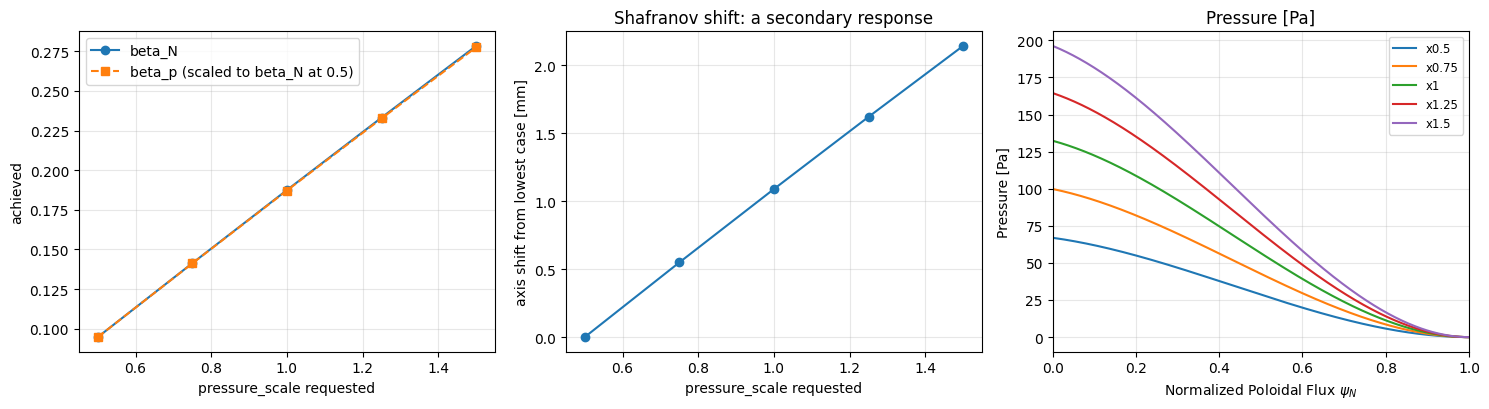

In [ ]:
if profile is not None:
    pscan = profile[(profile["current_peaking"] == 0.0)].sort_values("pressure_scale")
    print(pscan[["pressure_scale", "state", "beta_N", "beta_p", "li(3)", "q0", "q95", "R_axis [m]",
                 "volume [m3]", "GS residual"]].to_string(float_format="{:.5g}".format))
    ok = pscan[pscan["state"].isin(["valid", "new warnings"])]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    first = ok["pressure_scale"].iloc[0] if len(ok) else np.nan
    axes[0].plot(ok["pressure_scale"], ok["beta_N"], "o-", label="beta_N")
    if len(ok):
        axes[0].plot(ok["pressure_scale"], ok["beta_p"] * ok["beta_N"].iloc[0] / ok["beta_p"].iloc[0], "s--",
                     label=f"beta_p (scaled to beta_N at {first:g})")
    axes[0].set_xlabel("pressure_scale requested"); axes[0].set_ylabel("achieved"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(ok["pressure_scale"], 1e3 * (ok["R_axis [m]"] - ok["R_axis [m]"].iloc[0]), "o-")
    axes[1].set_xlabel("pressure_scale requested"); axes[1].set_ylabel("axis shift from lowest case [mm]"); axes[1].grid(alpha=0.3)
    axes[1].set_title("Shafranov shift: a secondary response")
    entries = [read_geqdsk(str(by_label[f"p{p:g}_c0"].result.refined_geqdsk)).to_omas() for p in ok["pressure_scale"]]
    vaft.omas.render_plot("equilibrium_profile_pressure", entries, label=[f"x{p:g}" for p in ok["pressure_scale"]],
                          coordinate="psi_norm", ax=axes[2])
    fig.tight_layout()

`β_N` and `β_p` follow the requested scale linearly. `l_i`, `q0` and `q95` hardly move, because the current profile is untouched. The magnetic axis moves outward with pressure (the Shafranov shift): the one secondary response this control has.

## 6. Current-profile peaking scan

`pressure_scale = 1`, `current_peaking` from 0 to 2. The `FF'` plotted is the **materialized** one, the profile CHEASE actually received.

         current_peaking  state  li(3)     q0   q95  shear@0.5  psi_N(q=1)  psi_N(q=1.5)  psi_N(q=2)  psi_N(q=3)  beta_N  Ip [kA]  GS residual
case                                                                                                                                          
p1_c0                  0  valid 0.5204  1.851 5.825      0.865         NaN           NaN      0.3031      0.7226  0.1874    137.9      0.01004
p1_c0.5              0.5  valid 0.7484  1.228 5.825      1.142         NaN        0.4431      0.6542      0.8139  0.2576    130.8     0.009442
p1_c1                  1  valid  1.011 0.8605 5.825      1.398      0.3587        0.6402      0.7479      0.8501  0.3391    122.2     0.009852
p1_c1.5              1.5  valid   1.29 0.6339 5.825      1.657      0.5556         0.713      0.7893       0.868  0.4261      113      0.01384
p1_c2                  2  valid  1.572 0.4848 5.825      1.927      0.6334        0.7501      0.8118      0.8783  0.5169    104.3      0.01137

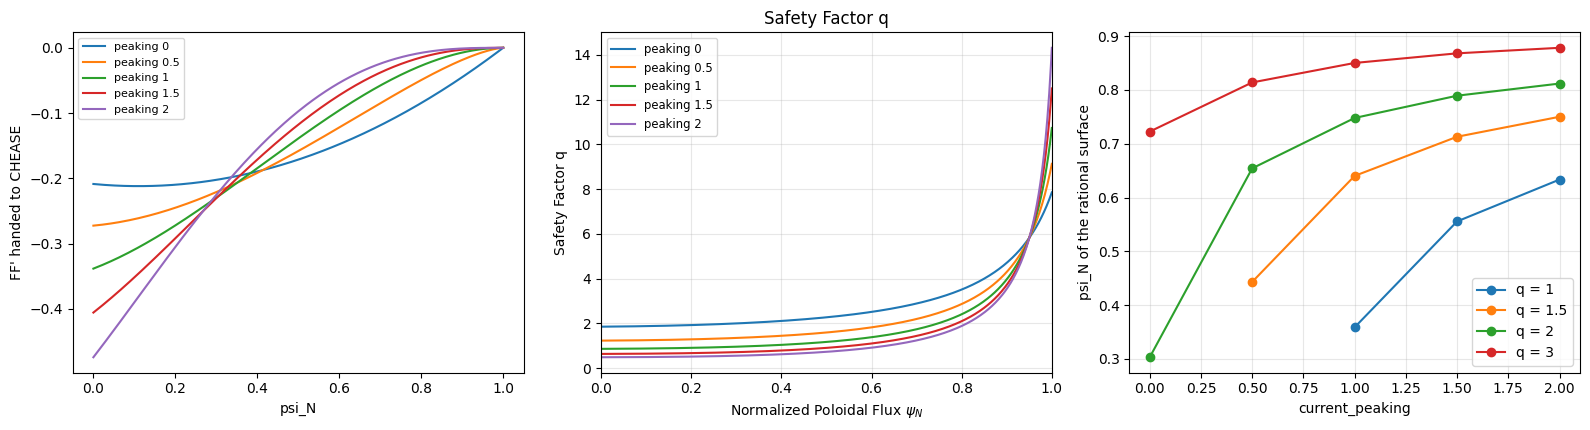

In [ ]:
if profile is not None:
    cscan = profile[(profile["pressure_scale"] == 1.0)].sort_values("current_peaking")
    print(cscan[["current_peaking", "state", "li(3)", "q0", "q95", "shear@0.5", "psi_N(q=1)", "psi_N(q=1.5)",
                 "psi_N(q=2)", "psi_N(q=3)", "beta_N", "Ip [kA]", "GS residual"]].to_string(float_format="{:.4g}".format))
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    ok = cscan[cscan["state"].isin(["valid", "new warnings"])]
    for c in ok["current_peaking"]:
        m = by_label[f"p1_c{c:g}"].result.materialized
        axes[0].plot(m.psi_norm, m.ffprime, label=f"peaking {c:g}")
    axes[0].set_xlabel("psi_N"); axes[0].set_ylabel("FF' handed to CHEASE"); axes[0].legend(fontsize=8)
    entries = [read_geqdsk(str(by_label[f"p1_c{c:g}"].result.refined_geqdsk)).to_omas() for c in ok["current_peaking"]]
    vaft.omas.render_plot("equilibrium_profile_q", entries, label=[f"peaking {c:g}" for c in ok["current_peaking"]],
                          coordinate="psi_norm", ax=axes[1])
    for q in RATIONAL_Q:
        axes[2].plot(ok["current_peaking"], ok[f"psi_N(q={q:g})"], "o-", label=f"q = {q:g}")
    axes[2].set_xlabel("current_peaking"); axes[2].set_ylabel("psi_N of the rational surface"); axes[2].legend(); axes[2].grid(alpha=0.3)
    fig.tight_layout()

This is the control that moves `l_i`, and with it the whole `q` profile. `q0` falls through 1 between peaking 0.5 and 1, so a `q = 1` surface appears, and every rational surface moves outward with more peaking. `q95` stays held, which is why the edge of the `q` profile barely moves while its core drops. That is the stability-relevant content of this scan: the same boundary and the same `q95` can have a `q = 1` surface or not, depending only on how peaked the current is.

## 7. Pressure × peaking grid

The same results as a 3 × 4 map. Cells are coloured only where the case is valid; any other state is written into the cell rather than interpolated over.

states: {'valid': 12}


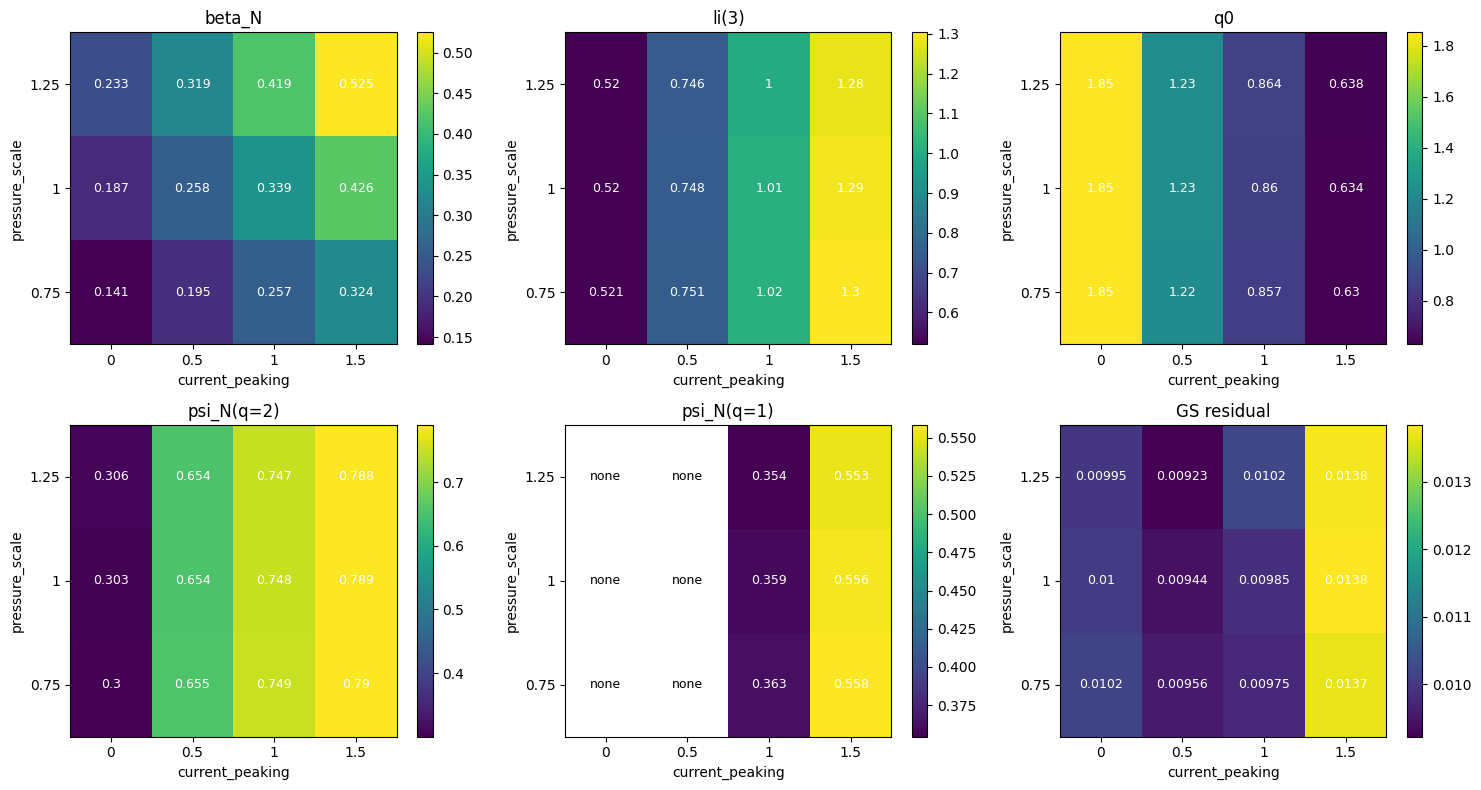

In [ ]:
if profile is not None:
    grid = profile[profile["pressure_scale"].isin(GRID_P) & profile["current_peaking"].isin(GRID_C)]
    quantities = ("beta_N", "li(3)", "q0", "psi_N(q=2)", "psi_N(q=1)", "GS residual")
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, quantity in zip(axes.ravel(), quantities):
        table = grid.pivot(index="pressure_scale", columns="current_peaking", values=quantity)
        states = grid.pivot(index="pressure_scale", columns="current_peaking", values="state")
        shown = table.where(states.isin(["valid", "new warnings"]))
        image = ax.imshow(shown.values.astype(float), origin="lower", aspect="auto", cmap="viridis")
        for (i, j), value in np.ndenumerate(table.values):
            valid = states.values[i, j] in ("valid", "new warnings")
            text = states.values[i, j] if not valid else ("none" if np.isnan(value) else f"{value:.3g}")
            # An uncoloured (blank) cell needs dark text to be read at all.
            ax.text(j, i, text, ha="center", va="center", fontsize=9,
                    color="w" if valid and not np.isnan(value) else "k")
        ax.set_xticks(range(len(table.columns)), [f"{c:g}" for c in table.columns])
        ax.set_yticks(range(len(table.index)), [f"{p:g}" for p in table.index])
        ax.set_xlabel("current_peaking"); ax.set_ylabel("pressure_scale"); ax.set_title(quantity)
        fig.colorbar(image, ax=ax)
    fig.tight_layout()
    print("states:", grid["state"].value_counts().to_dict())

The maps show the coupling of section 4 at a glance. `l_i`, `q0` and the rational surfaces vary along the peaking axis only. `β_N` varies along **both** axes: requested pressure and, through the q95-held rescale, current peaking. "none" marks where the rational surface is not in the plasma, for example no `q = 1` surface while `q0 > 1`.

## 8. Shape scan

This scan waits until the shape actually reaches CHEASE, which is issue #887's first question. Until #978, `scan_chease` rewrote only `RBBBS`. At `target_psin < 1` the adapter traces the `EXPEQ` boundary from the unchanged flux map instead, so CHEASE solved the unperturbed shape, and the refined g-file (whose `RBBBS` is restored from the input) reported the requested one anyway. A scan with any shape variation now solves every case, control included, on the Miller boundary at `target_psin = 1`. Each case writes that choice to `scan_boundary.json`.

For each case the table therefore keeps four shapes apart:
- **requested**: the Miller κ/δ `scan_chease` asked for (`case.shape`);
- **materialized**: the `EXPEQ` boundary CHEASE was handed;
- **solved**: CHEASE's own boundary in the refined g-file;
- **restored**: what `preserve_boundary_limiter=True`, the production default, would write, which is the requested outline copied back. That is why it cannot be evidence of anything.

Each solve is fixed-boundary *within* its case; the prescribed boundary differs *between* cases. The shape controls are relative to this discharge's own Miller fit. A deliberately absurd `elongation_scale = 25` is included as the failure probe of section 9.

In [ ]:
shape_variations = [
    EquilibriumVariation("control"),
    EquilibriumVariation("kappa x0.9", elongation_scale=0.9),
    EquilibriumVariation("kappa x1.1", elongation_scale=1.1),
    EquilibriumVariation("delta -0.05", triangularity_shift=-0.05),
    EquilibriumVariation("delta +0.05", triangularity_shift=0.05),
    EquilibriumVariation("delta +0.10", triangularity_shift=0.10),
    EquilibriumVariation("kappa x25", elongation_scale=25.0),
]


def boundary_shape(r, z):
    shape = contour_shape_parameters(np.asarray(r), np.asarray(z))
    return shape["elongation"], shape["triangularity_upper"]


shape_cases = shape = None
if executable is not None:
    started = time.time()
    shape_cases = scan_chease(str(source_path), shape_variations, config=config, workdir=workdir / "shape")
    shape = tabulate(
        shape_cases,
        solved_target_psin=lambda c: c.target_psin,
        **{
            "requested kappa": lambda c: c.shape[2] if c.shape else np.nan,
            "requested delta": lambda c: c.shape[3] if c.shape else np.nan,
            "materialized kappa": lambda c: boundary_shape(*c.result.materialized.boundary.T)[0] if c.result and c.result.materialized else np.nan,
            "materialized delta": lambda c: boundary_shape(*c.result.materialized.boundary.T)[1] if c.result and c.result.materialized else np.nan,
        },
    )
    # Not a measurement: preserve_boundary_limiter=True copies the requested outline back.
    shape["restored (= requested) kappa"] = shape["requested kappa"]
    shape["restored (= requested) delta"] = shape["requested delta"]
    print(f"{len(shape_cases)} cases in {time.time() - started:.0f} s")
    print(shape[["solved_target_psin", "requested kappa", "materialized kappa", "kappa", "restored (= requested) kappa",
                 "requested delta", "materialized delta", "delta_u", "restored (= requested) delta", "state"]]
          .rename(columns={"kappa": "solved kappa", "delta_u": "solved delta"}).to_string(float_format="{:.4f}".format))

7 cases in 449 s
             solved_target_psin  requested kappa  materialized kappa  solved kappa  restored (= requested) kappa  requested delta  materialized delta  solved delta  restored (= requested) delta              state
case                                                                                                                                                                                                                
control                  1.0000           1.7684              1.7674        1.7682                        1.7684           0.3199              0.3184        0.3192                        0.3199              valid
kappa x0.9               1.0000           1.5916              1.5913        1.5914                        1.5916           0.3199              0.3184        0.3194                        0.3199              valid
kappa x1.1               1.0000           1.9452              1.9453        1.9448                        1.9452           0.3199  

             beta_N  beta_p  li(3)    q0   q95  psi_N(q=2)  psi_N(q=3)  R_axis [m]  volume [m3]  GS residual
case                                                                                                        
control      0.1878  0.0239 0.5236 1.855 5.825      0.3281      0.7312      0.4221        1.022    0.0008178
kappa x0.9   0.1836 0.02489 0.5487  1.86 5.825      0.3006      0.7211      0.4198       0.9201    0.0007377
kappa x1.1   0.1915 0.02289 0.4988 1.861 5.825      0.3476        0.74      0.4238        1.125    0.0009883
delta -0.05  0.1825 0.02439 0.5286 1.914 5.825      0.2567      0.7184      0.4233        1.036    0.0006326
delta +0.05  0.1935 0.02343 0.5187 1.796 5.825      0.3857      0.7439      0.4208        1.008     0.001061
delta +0.10  0.1998 0.02297 0.5139 1.737 5.825      0.4348      0.7565      0.4195       0.9926     0.001392


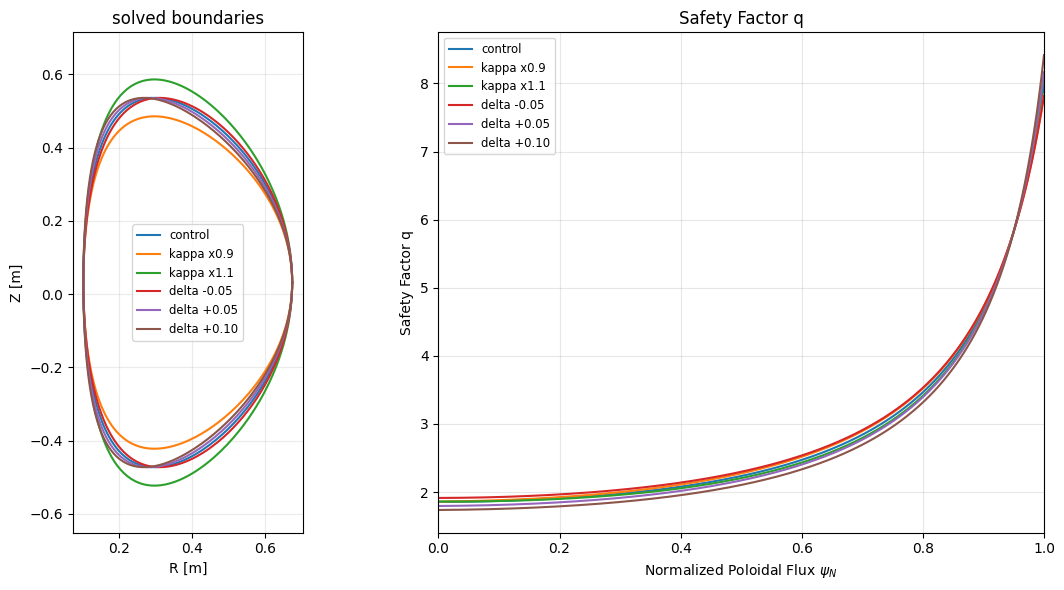

In [ ]:
if shape is not None:
    ok = shape[shape["state"].isin(["valid", "new warnings"])]
    print(ok[["beta_N", "beta_p", "li(3)", "q0", "q95", "psi_N(q=2)", "psi_N(q=3)", "R_axis [m]", "volume [m3]", "GS residual"]]
          .to_string(float_format="{:.4g}".format))
    by_shape = {case.variation.label: case for case in shape_cases}
    entries = [read_geqdsk(str(by_shape[label].result.refined_geqdsk)).to_omas() for label in ok.index]
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    vaft.omas.plot_equilibrium_geometry_boundary(entries, label=list(ok.index), ax=axes[0])
    axes[0].set_title("solved boundaries")
    vaft.omas.render_plot("equilibrium_profile_q", entries, label=list(ok.index), coordinate="psi_norm", ax=axes[1])
    fig.tight_layout()

Reading the shape tables:

- **κ** reaches the solve. The materialized and solved elongation follow the requested ratio: ×0.9 and ×1.1 of the control.
- **δ** reaches it too. The materialized and solved δ move by the requested shift. They sit a constant ~0.001-0.002 below the requested Miller δ, which is the resampling of the Miller curve for `EXPEQ`.
- **The restored column** equals the requested one by construction, whatever CHEASE solved: it is not evidence.
- **The control** solves on the Miller representation of the LCFS at `target_psin = 1`, so it is not the profile scans' baseline, and every shape derivative below is taken against it. Its Grad-Shafranov residual is an order of magnitude below the profile scans' (≈0.1% against ≈1%): a smooth analytic boundary is easier for CHEASE to hold than a traced flux contour.
- **Responses**: `l_i` falls and `β_N` rises with κ. With δ, `q0` falls, `β_N` rises and the `q = 2` surface moves outward, all at the same held `q95`.

## 9. Failures are results

At `elongation_scale = 25` the Miller boundary has an elongation near 40. **CHEASE solves it and exits 0.** The solve itself succeeds, and a scan that stopped at the exit code would take it. The shared validation says otherwise: the Grad-Shafranov residual exceeds 100% and the pressure is inconsistent with the flux map. That is the distinction this page draws throughout: a process that ran is not a self-consistent equilibrium. Every case is listed with its state, and none is dropped.

In [ ]:
if profile is not None and shape is not None:
    everything = pd.concat([profile.assign(scan="profile"), shape.assign(scan="shape")])
    print(everything[["scan", "state", "validation", "GS residual", "flags", "error"]].to_string(float_format="{:.4g}".format))
    print("\nstates:", everything["state"].value_counts().to_dict())

                scan              state validation  GS residual                                              flags error
case                                                                                                                    
p0.5_c0      profile              valid       warn      0.01024              pressure_profile, virial_conditioning      
p0.75_c0     profile              valid       warn      0.01017              pressure_profile, virial_conditioning      
p0.75_c0.5   profile              valid       warn     0.009558                                   pressure_profile      
p0.75_c1     profile              valid       warn      0.00975                                   pressure_profile      
p0.75_c1.5   profile              valid       warn      0.01369                                   pressure_profile      
p1_c0        profile              valid       warn      0.01004              pressure_profile, virial_conditioning      
p1_c0.5      profile            

## 10. Local response matrix

The sensitivity of achieved descriptor y_i to control u_j, by central differences around each scan's own baseline:

- **multiplicative controls** (`pressure_scale`, `elongation_scale`): S = ∂ln y / ∂ln u, a dimensionless elasticity.
- **additive controls whose baseline is zero** (`current_peaking`, `triangularity_shift`): S = ∂ln y / ∂u. A logarithmic derivative in u is undefined at u = 0. `current_peaking` uses a one-sided difference, since it cannot go negative.

The raw values are printed beside the heat map, so the normalization stays inspectable. A local sensitivity describes this baseline only.

             pressure_scale (dln/dln)  current_peaking (dln/du)  elongation_scale (dln/dln)  triangularity_shift (dln/du)
beta_N                         +0.980                    +0.636                      +0.210                        +0.588
beta_p                         +0.977                    +0.742                      -0.417                        -0.405
li(3)                          -0.001                    +0.727                      -0.475                        -0.190
q0                             +0.001                    -0.821                      +0.004                        -0.636
psi_N(q=3)                     +0.004                    +0.238                      +0.128                        +0.349
R_axis [m]                     +0.005                    +0.024                      +0.046                        -0.060
volume [m3]                    -0.000                    -0.000                      +1.000                        -0.279


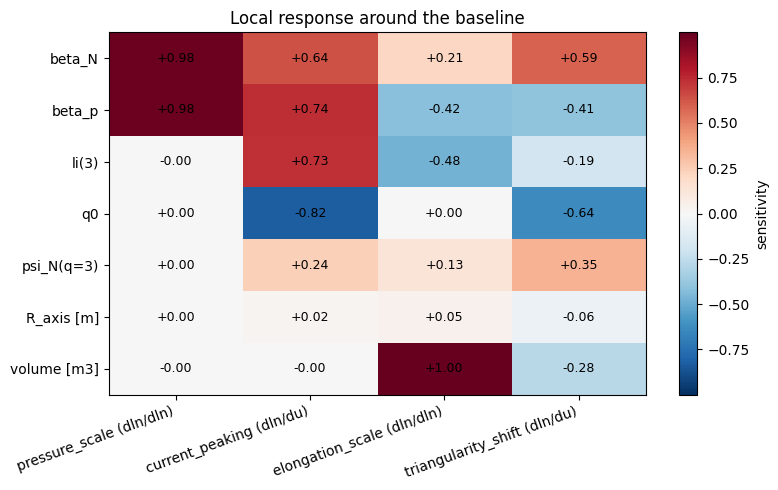

In [ ]:
OUTPUTS = ["beta_N", "beta_p", "li(3)", "q0", "psi_N(q=3)", "R_axis [m]", "volume [m3]"]


def ln_difference(table, low, high, step):
    """Finite difference of ln(y); NaN where either end is not a usable solve."""
    usable = table["state"].isin(["valid", "new warnings"])
    if not (usable.get(low, False) and usable.get(high, False)):
        return pd.Series(np.nan, index=OUTPUTS)
    ends = table.loc[[low, high]].reindex(columns=OUTPUTS).astype(float)
    return (np.log(ends.loc[high]) - np.log(ends.loc[low])) / step


if profile is not None and shape is not None:
    response = pd.DataFrame({
        "pressure_scale (dln/dln)": ln_difference(profile, "p0.75_c0", "p1.25_c0", np.log(1.25 / 0.75)),
        "current_peaking (dln/du)": ln_difference(profile, "p1_c0", "p1_c0.5", 0.5),
        "elongation_scale (dln/dln)": ln_difference(shape, "kappa x0.9", "kappa x1.1", np.log(1.1 / 0.9)),
        "triangularity_shift (dln/du)": ln_difference(shape, "delta -0.05", "delta +0.05", 0.10),
    })
    print(response.to_string(float_format="{:+.3f}".format))
    fig, ax = plt.subplots(figsize=(8, 5))
    limit = float(np.nanmax(np.abs(response.values)))
    image = ax.imshow(response.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
    ax.set_xticks(range(response.shape[1]), response.columns, rotation=20, ha="right")
    ax.set_yticks(range(response.shape[0]), response.index)
    for (i, j), value in np.ndenumerate(response.values):
        ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=9)
    fig.colorbar(image, ax=ax, label="sensitivity")
    ax.set_title("Local response around the baseline")
    fig.tight_layout()

In the matrix, a column is a control and a row is an achieved quantity.
- **Pressure** is close to a pure β control: its elasticity is about 1 for `β_N` and `β_p` and near 0 elsewhere.
- **Peaking** moves almost everything, `β_N` included, which is the coupling of section 4.
- **Elongation** moves the volume one to one; `l_i` and `β_p` fall while `β_N` rises.

Where a column has several large entries, that control cannot be used to set one descriptor without moving the others.

## 11. What reaches DCON / RDCON / GPEC

For a stability calculation, the scans above show which inputs move which of the quantities those codes are sensitive to:
- **current peaking** controls `q0`, the existence of a `q = 1` surface, the positions of every rational surface, and `l_i`: the internal-kink and tearing inputs.
- **pressure** controls β and the Shafranov shift, at nearly fixed `q`: the pressure-driven, ballooning and interchange inputs.
- **shaping** moves the volume and `l_i`, and through δ the `q = 2` surface, at held `q95`.

The stability codes themselves are not run here. Every valid case is a qualified CHEASE equilibrium: solved, with residual and validation recorded. Any of them can be handed to DCON, and should be reported with the controls and the `target_psin` that produced it.

## Cleanup

In [ ]:
if workdir.exists():
    _size_mb = sum(p.stat().st_size for p in workdir.rglob("*") if p.is_file()) / 1e6
    print(f"releasing the work directory ({_size_mb:.0f} MB)")
_cleanup.close()
print(f"removed: {not workdir.exists()}")

releasing the work directory (339 MB)


removed: True
